# Final Project: Recommendation Systems

**Team Members:** Yaseen Islam - Nadine Emad 

## Part 1: Data Loading & Preprocessing

---

### Objectives:
1. Load all relevant CSV files and merge them appropriately
2. Report the number of users, movies, and ratings
3. Handle any missing values or duplicate entries
4. Construct the User-Item utility matrix
5. Report the sparsity of the utility matrix

## Setup and Imports

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.2.3
NumPy version: 2.1.3


## 1. Load All CSV Files

We'll load the four main files from the MovieLens dataset:
- `ratings.csv` - User ratings for movies
- `movies.csv` - Movie metadata (title, genres)
- `tags.csv` - User-generated tags
- `links.csv` - External IDs (IMDb, TMDb)

In [85]:
# Define the path to your dataset
# Update this path to where you've extracted the ml-latest-small folder
dataset_path = Path("ml-latest-small")

# Load all CSV files
ratings = pd.read_csv(dataset_path / "ratings.csv")
movies = pd.read_csv(dataset_path / "movies.csv")
tags = pd.read_csv(dataset_path / "tags.csv")
links = pd.read_csv(dataset_path / "links.csv")

print("✓ All files loaded successfully!")
print(f"\nDataset shapes:")
print(f"  Ratings: {ratings.shape}")
print(f"  Movies:  {movies.shape}")
print(f"  Tags:    {tags.shape}")
print(f"  Links:   {links.shape}")

✓ All files loaded successfully!

Dataset shapes:
  Ratings: (100836, 4)
  Movies:  (9742, 3)
  Tags:    (3683, 4)
  Links:   (9742, 3)


### 1.1 Initial Data Inspection

In [86]:
# Inspect ratings data
print("RATINGS DataFrame:")
print("="*80)
display(ratings.head(10))
print(f"\nColumns: {ratings.columns.tolist()}")
print(f"\nData types:\n{ratings.dtypes}")
print(f"\nShape: {ratings.shape}")

RATINGS DataFrame:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100



Columns: ['userId', 'movieId', 'rating', 'timestamp']

Data types:
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

Shape: (100836, 4)


In [87]:
# Inspect movies data
print("MOVIES DataFrame:")
print("="*80)
display(movies.head(10))
print(f"\nColumns: {movies.columns.tolist()}")
print(f"\nData types:\n{movies.dtypes}")

MOVIES DataFrame:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller



Columns: ['movieId', 'title', 'genres']

Data types:
movieId     int64
title      object
genres     object
dtype: object


In [88]:
# Inspect tags data
print("TAGS DataFrame:")
print("="*80)
display(tags.head(10))
print(f"\nColumns: {tags.columns.tolist()}")

TAGS DataFrame:


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
5,2,89774,Tom Hardy,1445715205
6,2,106782,drugs,1445715054
7,2,106782,Leonardo DiCaprio,1445715051
8,2,106782,Martin Scorsese,1445715056
9,7,48516,way too long,1169687325



Columns: ['userId', 'movieId', 'tag', 'timestamp']


In [89]:
# Inspect links data
print("LINKS DataFrame:")
print("="*80)
display(links.head(10))
print(f"\nColumns: {links.columns.tolist()}")

LINKS DataFrame:


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0
5,6,113277,949.0
6,7,114319,11860.0
7,8,112302,45325.0
8,9,114576,9091.0
9,10,113189,710.0



Columns: ['movieId', 'imdbId', 'tmdbId']


## 2. Report Basic Statistics

Let's calculate and report the key statistics about our dataset.

In [90]:
# Calculate basic statistics
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)

print("="*80)
print("DATASET STATISTICS")
print("="*80)
print(f"\n📊 Overview:")
print(f"   • Number of unique users:     {num_users:,}")
print(f"   • Number of unique movies:    {num_movies:,}")
print(f"   • Total number of ratings:    {num_ratings:,}")
print(f"   • Total movies in catalog:    {len(movies):,}")
print(f"   • Total number of tags:       {len(tags):,}")
print(f"   • Unique tags:                {tags['tag'].nunique():,}")

DATASET STATISTICS

📊 Overview:
   • Number of unique users:     610
   • Number of unique movies:    9,724
   • Total number of ratings:    100,836
   • Total movies in catalog:    9,742
   • Total number of tags:       3,683
   • Unique tags:                1,589


In [91]:
# Rating statistics
print("\n📈 Rating Distribution:")
print(f"   • Rating range:      {ratings['rating'].min()} to {ratings['rating'].max()}")
print(f"   • Mean rating:       {ratings['rating'].mean():.3f}")
print(f"   • Median rating:     {ratings['rating'].median():.3f}")
print(f"   • Std deviation:     {ratings['rating'].std():.3f}")
print(f"\n   Value counts:")
print(ratings['rating'].value_counts().sort_index())


📈 Rating Distribution:
   • Rating range:      0.5 to 5.0
   • Mean rating:       3.502
   • Median rating:     3.500
   • Std deviation:     1.043

   Value counts:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


In [92]:
# User activity statistics
ratings_per_user = ratings.groupby('userId').size()

print("\n👤 User Activity:")
print(f"   • Average ratings per user:  {ratings_per_user.mean():.2f}")
print(f"   • Median ratings per user:   {ratings_per_user.median():.0f}")
print(f"   • Min ratings per user:      {ratings_per_user.min()}")
print(f"   • Max ratings per user:      {ratings_per_user.max()}")
print(f"   • Std deviation:             {ratings_per_user.std():.2f}")


👤 User Activity:
   • Average ratings per user:  165.30
   • Median ratings per user:   70
   • Min ratings per user:      20
   • Max ratings per user:      2698
   • Std deviation:             269.48


In [93]:
# Movie popularity statistics
ratings_per_movie = ratings.groupby('movieId').size()

print("\n🎬 Movie Popularity:")
print(f"   • Average ratings per movie: {ratings_per_movie.mean():.2f}")
print(f"   • Median ratings per movie:  {ratings_per_movie.median():.0f}")
print(f"   • Min ratings per movie:     {ratings_per_movie.min()}")
print(f"   • Max ratings per movie:     {ratings_per_movie.max()}")
print(f"   • Std deviation:             {ratings_per_movie.std():.2f}")


🎬 Movie Popularity:
   • Average ratings per movie: 10.37
   • Median ratings per movie:  3
   • Min ratings per movie:     1
   • Max ratings per movie:     329
   • Std deviation:             22.40


## 3. Handle Missing Values and Duplicates

Before constructing the utility matrix, we need to ensure data quality by:
1. Identifying and handling missing values
2. Detecting and removing duplicate entries

### 3.1 Missing Values Analysis

In [94]:
print("="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

print("\nRatings DataFrame:")
print(ratings.isnull().sum())
print(f"Total missing: {ratings.isnull().sum().sum()}")

print("\nMovies DataFrame:")
print(movies.isnull().sum())
print(f"Total missing: {movies.isnull().sum().sum()}")

print("\nTags DataFrame:")
print(tags.isnull().sum())
print(f"Total missing: {tags.isnull().sum().sum()}")

print("\nLinks DataFrame:")
print(links.isnull().sum())
print(f"Total missing: {links.isnull().sum().sum()}")

MISSING VALUES ANALYSIS

Ratings DataFrame:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Total missing: 0

Movies DataFrame:
movieId    0
title      0
genres     0
dtype: int64
Total missing: 0

Tags DataFrame:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64
Total missing: 0

Links DataFrame:
movieId    0
imdbId     0
tmdbId     8
dtype: int64
Total missing: 8


In [95]:
# Handle missing values

# Clean tags (drop any rows with missing values)
tags_clean = tags.dropna()
print(f"Tags: {len(tags)} → {len(tags_clean)} rows (removed {len(tags) - len(tags_clean)} with missing values)")

# Clean movies (keep all, but note if any have missing genres)
movies_clean = movies.copy()
if movies['genres'].isnull().any():
    print(f"\n⚠️  Warning: {movies['genres'].isnull().sum()} movies have missing genres")
    print("Movies with missing genres:")
    display(movies[movies['genres'].isnull()])
else:
    print("\n✓ All movies have genre information")

Tags: 3683 → 3683 rows (removed 0 with missing values)

✓ All movies have genre information


### 3.2 Duplicate Detection and Removal

In [96]:
print("="*80)
print("DUPLICATE ANALYSIS")
print("="*80)

# Check for duplicate ratings (same user rating same movie multiple times)
duplicate_mask = ratings.duplicated(subset=['userId', 'movieId'], keep=False)
num_duplicates = duplicate_mask.sum()

print(f"\nNumber of duplicate user-movie pairs: {num_duplicates}")

if num_duplicates > 0:
    print("\nExample duplicates:")
    duplicate_examples = ratings[duplicate_mask].sort_values(['userId', 'movieId', 'timestamp']).head(20)
    display(duplicate_examples)
    
    # Strategy: Keep the most recent rating (latest timestamp)
    print("\n📝 Strategy: Keeping the most recent rating for each user-movie pair...")
    ratings_clean = ratings.sort_values('timestamp').groupby(['userId', 'movieId'], as_index=False).last()
    print(f"   Ratings before: {len(ratings):,}")
    print(f"   Ratings after:  {len(ratings_clean):,}")
    print(f"   Removed:        {len(ratings) - len(ratings_clean):,}")
else:
    ratings_clean = ratings.copy()
    print("\n✓ No duplicate user-movie pairs found")

DUPLICATE ANALYSIS

Number of duplicate user-movie pairs: 0

✓ No duplicate user-movie pairs found


## 4. Merge Datasets Appropriately

We'll merge the ratings with movie information to create a complete dataset.

In [97]:

ratings_with_movies = ratings_clean.merge(movies_clean, on='movieId', how='left')

print("Merged ratings with movies:")
print(f"Shape: {ratings_with_movies.shape}")
print(f"\nColumns: {ratings_with_movies.columns.tolist()}")
print("\nSample data:")
display(ratings_with_movies.head(10))

# Check for ratings without movie information
missing_movie_info = ratings_with_movies['title'].isnull().sum()
if missing_movie_info > 0:
    print(f"\n⚠️  Warning: {missing_movie_info} ratings have no corresponding movie info")
else:
    print("\n✓ All ratings successfully matched with movie information")

Merged ratings with movies:
Shape: (100836, 6)

Columns: ['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres']

Sample data:


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
5,1,70,3.0,964982400,From Dusk Till Dawn (1996),Action|Comedy|Horror|Thriller
6,1,101,5.0,964980868,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance
7,1,110,4.0,964982176,Braveheart (1995),Action|Drama|War
8,1,151,5.0,964984041,Rob Roy (1995),Action|Drama|Romance|War
9,1,157,5.0,964984100,Canadian Bacon (1995),Comedy|War



✓ All ratings successfully matched with movie information


In [98]:
# Optional: Create complete dataset with links (for potential future use)
complete_data = ratings_with_movies.merge(links, on='movieId', how='left')
print(f"Complete dataset with links: {complete_data.shape}")
display(complete_data.head())

Complete dataset with links: (100836, 8)


,userId,movieId,rating,timestamp,title,genres,imdbId,tmdbId
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,113277,949.0
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,114369,807.0
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114814,629.0


## 5. Construct User-Item Utility Matrix

The utility matrix is a 2D matrix where:
- **Rows** represent users
- **Columns** represent movies
- **Values** are ratings (1.0 to 5.0)
- **NaN** indicates unrated pairs

This is the core data structure for our recommendation system.

In [99]:
print("="*80)
print("CONSTRUCTING UTILITY MATRIX")
print("="*80)

# Create utility matrix using pivot
utility_matrix = ratings_clean.pivot(
    index='userId',
    columns='movieId',
    values='rating'
)

print(f"\n✓ Utility matrix created successfully!")
print(f"\nDimensions: {utility_matrix.shape[0]:,} users × {utility_matrix.shape[1]:,} movies")
print(f"Memory usage: {utility_matrix.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nData type: {utility_matrix.dtypes.iloc[0]}")

CONSTRUCTING UTILITY MATRIX

✓ Utility matrix created successfully!

Dimensions: 610 users × 9,724 movies
Memory usage: 45.26 MB

Data type: float64


In [100]:
# Display a sample of the utility matrix
print("\nUtility Matrix Sample (first 10 users, first 10 movies):")
display(utility_matrix.iloc[:10, :10])

print("\nNote: NaN values represent movies that have not been rated by the user")


Utility Matrix Sample (first 10 users, first 10 movies):


movieId,1,2,3,4,5,6,7,8,9,10
userId,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,3.0,5.0,4.0,4.0,3.0,NaN,3.0
7,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Note: NaN values represent movies that have not been rated by the user


In [101]:
# Verify the utility matrix
print("\nUtility Matrix Verification:")
print(f"Number of users (rows): {utility_matrix.shape[0]:,}")
print(f"Number of movies (columns): {utility_matrix.shape[1]:,}")
print(f"Total cells in matrix: {utility_matrix.shape[0] * utility_matrix.shape[1]:,}")
print(f"Number of ratings (non-NaN values): {utility_matrix.notna().sum().sum():,}")
print(f"Number of missing values (NaN): {utility_matrix.isna().sum().sum():,}")


Utility Matrix Verification:
Number of users (rows): 610
Number of movies (columns): 9,724
Total cells in matrix: 5,931,640
Number of ratings (non-NaN values): 100,836
Number of missing values (NaN): 5,830,804


## 6. Report Sparsity of Utility Matrix

**Sparsity** is the percentage of missing (unrated) entries in the utility matrix. High sparsity is typical in recommendation systems because:
- Users typically rate only a small fraction of available items
- Most user-item pairs have no interaction

**Formula:** Sparsity = (Number of NaN entries / Total entries) × 100%

In [102]:
# Calculate sparsity metrics
total_cells = utility_matrix.shape[0] * utility_matrix.shape[1]
num_ratings = utility_matrix.notna().sum().sum()
num_missing = utility_matrix.isna().sum().sum()
sparsity = (num_missing / total_cells) * 100
density = 100 - sparsity

print("="*80)
print("SPARSITY ANALYSIS")
print("="*80)

print(f"\n📊 Sparsity Metrics:")
print(f"   • Total matrix cells:        {total_cells:,}")
print(f"   • Filled cells (ratings):    {num_ratings:,}")
print(f"   • Empty cells (NaN):         {num_missing:,}")
print(f"   • Sparsity:                  {sparsity:.4f}%")
print(f"   • Density:                   {density:.4f}%")

SPARSITY ANALYSIS

📊 Sparsity Metrics:
   • Total matrix cells:        5,931,640
   • Filled cells (ratings):    100,836
   • Empty cells (NaN):         5,830,804
   • Sparsity:                  98.3000%
   • Density:                   1.7000%


In [103]:
# Additional insights
avg_ratings_per_user = num_ratings / utility_matrix.shape[0]
avg_ratings_per_movie = num_ratings / utility_matrix.shape[1]

print(f"\n📈 Additional Insights:")
print(f"   • Average ratings per user:  {avg_ratings_per_user:.2f} out of {utility_matrix.shape[1]:,} movies")
print(f"   • Average ratings per movie: {avg_ratings_per_movie:.2f} out of {utility_matrix.shape[0]:,} users")
print(f"   • Coverage per user:         {(avg_ratings_per_user/utility_matrix.shape[1])*100:.4f}%")
print(f"   • Coverage per movie:        {(avg_ratings_per_movie/utility_matrix.shape[0])*100:.4f}%")


📈 Additional Insights:
   • Average ratings per user:  165.30 out of 9,724 movies
   • Average ratings per movie: 10.37 out of 610 users
   • Coverage per user:         1.7000%
   • Coverage per movie:        1.7000%


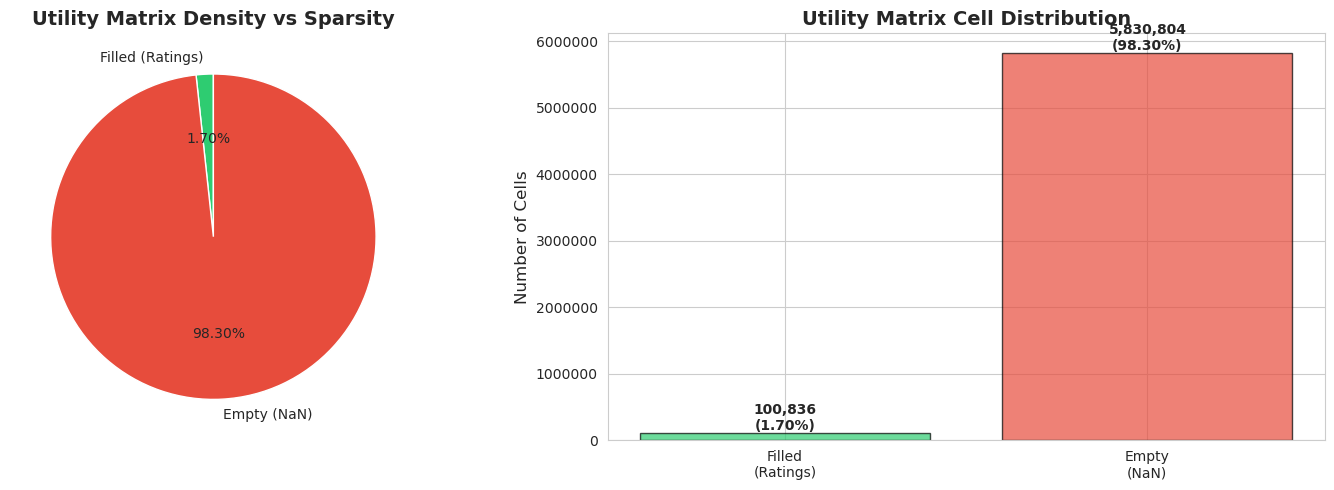


✓ Sparsity visualization saved as 'sparsity_visualization.png'


In [104]:
# Visualize sparsity
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pie chart
axes[0].pie([density, sparsity], 
            labels=['Filled (Ratings)', 'Empty (NaN)'],
            autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[0].set_title('Utility Matrix Density vs Sparsity', fontsize=14, fontweight='bold')

# Bar chart
categories = ['Filled\n(Ratings)', 'Empty\n(NaN)']
values = [num_ratings, num_missing]
colors = ['#2ecc71', '#e74c3c']

bars = axes[1].bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Number of Cells', fontsize=12)
axes[1].set_title('Utility Matrix Cell Distribution', fontsize=14, fontweight='bold')
axes[1].ticklabel_format(style='plain', axis='y')

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{value:,}\n({(value/total_cells)*100:.2f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
# plt.savefig('sparsity_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Sparsity visualization saved as 'sparsity_visualization.png'")

## 8. Summary for Report

This section provides a concise summary of all findings for inclusion in the final report.

In [105]:
summary_text = f"""
{'='*80}
PART 1: DATA LOADING & PREPROCESSING - SUMMARY
{'='*80}

DATASET OVERVIEW:
  • Total Users:                {num_users:,}
  • Total Movies:               {num_movies:,}
  • Total Ratings:              {num_ratings:,}
  • Rating Scale:               {ratings['rating'].min()} to {ratings['rating'].max()}
  • Mean Rating:                {ratings['rating'].mean():.3f}

UTILITY MATRIX:
  • Dimensions:                 {utility_matrix.shape[0]:,} users × {utility_matrix.shape[1]:,} movies
  • Total Cells:                {total_cells:,}
  • Filled Cells (Ratings):     {num_ratings:,}
  • Empty Cells (NaN):          {num_missing:,}
  • Sparsity:                   {sparsity:.4f}%
  • Density:                    {density:.4f}%

DATA QUALITY:
  • Duplicate ratings removed:  {num_duplicates}
  • Missing values handled:     Yes
  • Final cleaned ratings:      {len(ratings_clean):,}

KEY OBSERVATIONS:
  • The utility matrix is extremely sparse ({sparsity:.2f}% empty)
  • Each user has rated only {avg_ratings_per_user:.2f} movies on average
    ({(avg_ratings_per_user/utility_matrix.shape[1])*100:.4f}% of available movies)
  • Each movie has been rated by {avg_ratings_per_movie:.2f} users on average
    ({(avg_ratings_per_movie/utility_matrix.shape[0])*100:.4f}% of all users)
  • This extreme sparsity is typical for recommendation systems and presents
    both challenges (cold-start problem) and opportunities (personalization)

{'='*80}
"""

print(summary_text)

# Save summary to file
with open("part1_summary.txt", "w") as f:
    f.write(summary_text)

print("\n✓ Summary saved to 'part1_summary.txt'")


PART 1: DATA LOADING & PREPROCESSING - SUMMARY

DATASET OVERVIEW:
  • Total Users:                610
  • Total Movies:               9,724
  • Total Ratings:              100,836
  • Rating Scale:               0.5 to 5.0
  • Mean Rating:                3.502

UTILITY MATRIX:
  • Dimensions:                 610 users × 9,724 movies
  • Total Cells:                5,931,640
  • Filled Cells (Ratings):     100,836
  • Empty Cells (NaN):          5,830,804
  • Sparsity:                   98.3000%
  • Density:                    1.7000%

DATA QUALITY:
  • Duplicate ratings removed:  0
  • Missing values handled:     Yes
  • Final cleaned ratings:      100,836

KEY OBSERVATIONS:
  • The utility matrix is extremely sparse (98.30% empty)
  • Each user has rated only 165.30 movies on average
    (1.7000% of available movies)
  • Each movie has been rated by 10.37 users on average
    (1.7000% of all users)
  • This extreme sparsity is typical for recommendation systems and presents
    both 

# DATA PREPARATION FOR PART 2: CONTENT-BASED FILTERING


In [106]:


ratings_cbf = ratings_clean.copy()
ratings_cbf['shifted_rating'] = ratings_cbf['rating'] - 3.0

print(f"Shifted ratings generated. Shape: {ratings_cbf.shape}")

# ---------------------------------------------------------
# Prepare Item Profiles (Genres Vector + Stats)
# ---------------------------------------------------------

# One-Hot Encode the Genres
genre_vectors = movies_clean['genres'].str.get_dummies(sep='|')

# Calculate Movie Statistics (Average Rating & Count)
movie_stats = ratings_clean.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

# Combine everything into the final Item Profiles DataFrame
item_profiles = pd.concat([movies_clean[['movieId', 'title']], genre_vectors], axis=1)
item_profiles = item_profiles.merge(movie_stats, on='movieId', how='left')

# Handle movies with zero ratings (Cold-Start Items)
# If a movie has no ratings, its average is NaN. We fill it with the global average (3.5)
global_avg = ratings_clean['rating'].mean()
item_profiles['avg_rating'] = item_profiles['avg_rating'].fillna(global_avg)
item_profiles['num_ratings'] = item_profiles['num_ratings'].fillna(0)

print(f"Item profiles generated. Shape: {item_profiles.shape}")
print("\nFeature columns created:")
print(list(item_profiles.columns[2:])) 

# Display the first few rows to verify
display(item_profiles.head())

Shifted ratings generated. Shape: (100836, 5)
Item profiles generated. Shape: (9742, 24)

Feature columns created:
['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'avg_rating', 'num_ratings']


,movieId,title,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,avg_rating,num_ratings
0,1,Toy Story (1995),0,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,3.920930,215.0
1,2,Jumanji (1995),0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,3.431818,110.0
2,3,Grumpier Old Men (1995),0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,3.259615,52.0
3,4,Waiting to Exhale (1995),0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,2.357143,7.0
4,5,Father of the Bride Part II (1995),0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,3.071429,49.0



## DATA PREPARATION FOR PART 3: COLLABORATIVE FILTERING


In [107]:

print("--- Preparing Data for Collaborative Filtering ---")

# Create the Raw Utility Matrix
utility_matrix = ratings_clean.pivot(index='userId', columns='movieId', values='rating')

# Calculate each user's average rating (ignoring NaNs)
user_means = utility_matrix.mean(axis=1)

# Mean-Center the Matrix (Rating - User_Mean)
utility_matrix_centered = utility_matrix.sub(user_means, axis=0)

# Fill missing values with 0.0 (Neutral weight for Cosine Similarity)
cf_user_item_matrix = utility_matrix_centered.fillna(0)

# Transpose for Item-Item CF
cf_item_user_matrix = cf_user_item_matrix.T

print(f"User-User CF Matrix shape: {cf_user_item_matrix.shape}")
print(f"Item-Item CF Matrix shape: {cf_item_user_matrix.shape}")

--- Preparing Data for Collaborative Filtering ---
User-User CF Matrix shape: (610, 9724)
Item-Item CF Matrix shape: (9724, 610)


## 7. Save Processed Data



In [108]:
# SAVE PROCESSED DATASETS FOR PART 2 & 3 

print("Saving processed datasets for the next stages...")


# Save utility matrix
utility_matrix.to_csv("utility_matrix.csv")
print("✓ Saved: utility_matrix.csv")
# Save merged dataset
ratings_with_movies.to_csv("ratings_with_movies.csv", index=False)
print("✓ Saved: ratings_with_movies.csv")

# Base Cleaned Data 
ratings_clean.to_csv("ratings_clean.csv", index=False)
movies_clean.to_csv("movies_clean.csv", index=False)
tags_clean.to_csv("tags_clean.csv", index=False)


# Data: Content-Based Filtering
ratings_cbf.to_csv("cbf_shifted_ratings.csv", index=False)
item_profiles.to_csv("cbf_item_profiles.csv", index=False)
print("✓ Saved Part 2 (Content-Based) Data")

# Data: Collaborative Filtering
# Note: We save the mean-centered matrices here!
cf_user_item_matrix.to_csv("cf_user_user_matrix.csv")
cf_item_user_matrix.to_csv("cf_item_item_matrix.csv")
print("✓ Saved Part 3 (Collaborative) Data")

print("\n✓ All datasets saved successfully! Ready for modeling.")

Saving processed datasets for the next stages...
✓ Saved: utility_matrix.csv
✓ Saved: ratings_with_movies.csv
✓ Saved Part 2 (Content-Based) Data
✓ Saved Part 3 (Collaborative) Data

✓ All datasets saved successfully! Ready for modeling.



## Part 1.2: Exploratory Data Analysis (EDA)


## Setup and Imports

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Processed Data from Part 1.1

In [110]:
# Load the cleaned datasets from Part 1.1
ratings_clean = pd.read_csv("ratings_clean.csv")
movies_clean = pd.read_csv("movies_clean.csv")
utility_matrix = pd.read_csv("utility_matrix.csv", index_col=0)
ratings_with_movies = pd.read_csv("ratings_with_movies.csv")

print("✓ Data loaded successfully!")
print(f"\nDataset shapes:")
print(f"  Ratings: {ratings_clean.shape}")
print(f"  Movies:  {movies_clean.shape}")
print(f"  Utility Matrix: {utility_matrix.shape}")

✓ Data loaded successfully!

Dataset shapes:
  Ratings: (100836, 4)
  Movies:  (9742, 3)
  Utility Matrix: (610, 9724)


---
## 1. Distribution of Ratings (Histogram)


- What ratings are most common?
- Is the distribution skewed?
- Are users generally positive or negative in their ratings?

In [111]:
# Calculate statistics
rating_stats = ratings_clean['rating'].describe()
skewness = ratings_clean['rating'].skew()
kurtosis = ratings_clean['rating'].kurtosis()

print("="*80)
print("RATING DISTRIBUTION STATISTICS")
print("="*80)
print(rating_stats)
print(f"\nSkewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

RATING DISTRIBUTION STATISTICS
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Skewness: -0.6372
Kurtosis: 0.1233


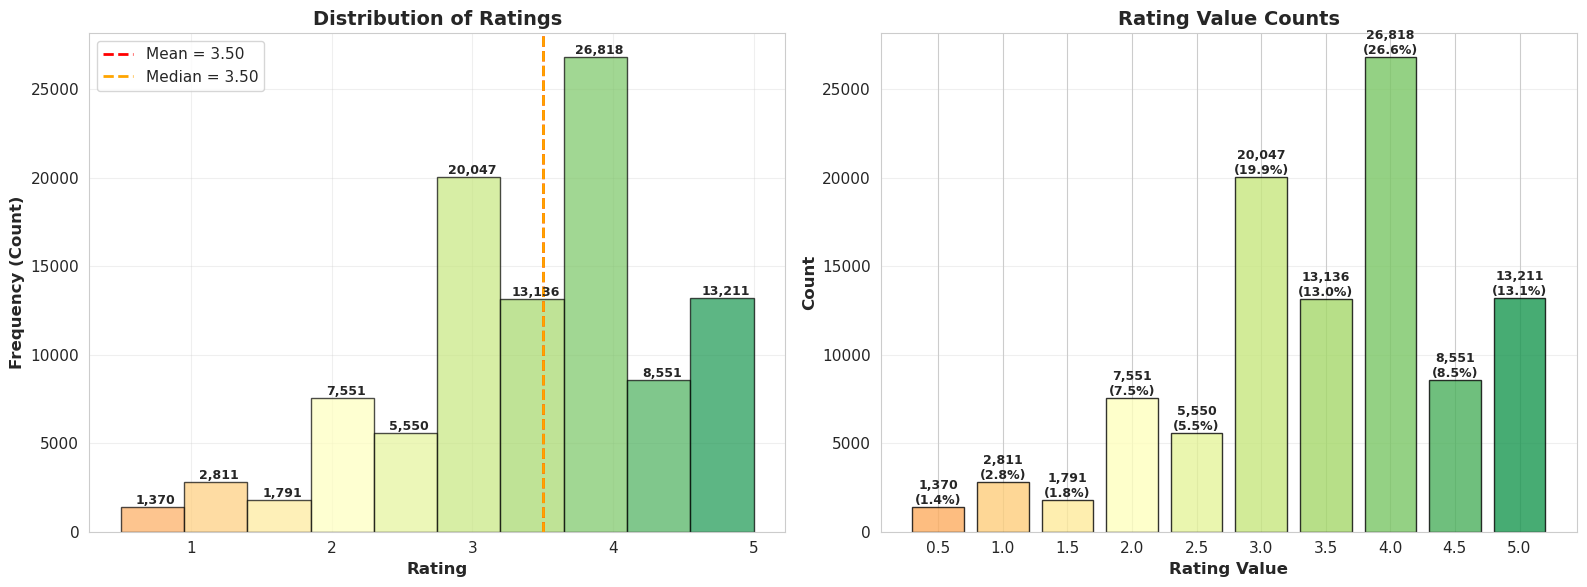


✓ Visualization saved as 'rating_distribution.png'


In [112]:
# Create detailed histogram with multiple visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Histogram with distribution curve
ax1 = axes[0]
n, bins, patches = ax1.hist(ratings_clean['rating'], bins=10, 
                             edgecolor='black', alpha=0.7, color='steelblue',
                             density=False)

# Color bars by rating value (gradient)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(patches)))
for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

ax1.axvline(ratings_clean['rating'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean = {ratings_clean["rating"].mean():.2f}')
ax1.axvline(ratings_clean['rating'].median(), color='orange', linestyle='--', 
            linewidth=2, label=f'Median = {ratings_clean["rating"].median():.2f}')

ax1.set_xlabel('Rating', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency (Count)', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Ratings', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Add count labels on bars
for i, (count, bin_edge) in enumerate(zip(n, bins[:-1])):
    if count > 0:
        ax1.text(bin_edge + 0.25, count, f'{int(count):,}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Right plot: Bar chart of rating value counts
ax2 = axes[1]
rating_counts = ratings_clean['rating'].value_counts().sort_index()
bars = ax2.bar(rating_counts.index, rating_counts.values, 
               width=0.4, edgecolor='black', alpha=0.8)

# Color bars
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(bars)))
for bar, color in zip(bars, colors):
    bar.set_facecolor(color)

ax2.set_xlabel('Rating Value', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Rating Value Counts', fontsize=14, fontweight='bold')
ax2.set_xticks(rating_counts.index)
ax2.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for idx, count in zip(rating_counts.index, rating_counts.values):
    ax2.text(idx, count, f'{count:,}\n({count/len(ratings_clean)*100:.1f}%)', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
# plt.savefig('rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'rating_distribution.png'")

### Analysis: Rating Distribution Skew

In [113]:
print("="*80)
print("SKEWNESS ANALYSIS")
print("="*80)

print(f"\n📊 Distribution Statistics:")
print(f"   • Mean: {ratings_clean['rating'].mean():.3f}")
print(f"   • Median: {ratings_clean['rating'].median():.3f}")
print(f"   • Mode: {ratings_clean['rating'].mode()[0]:.1f}")
print(f"   • Skewness: {skewness:.4f}")

# Interpret skewness
if skewness < -0.5:
    skew_interpretation = "NEGATIVELY SKEWED (left-skewed)"
    skew_meaning = "The distribution has a long tail on the left side. More ratings are concentrated on the higher end."
elif skewness > 0.5:
    skew_interpretation = "POSITIVELY SKEWED (right-skewed)"
    skew_meaning = "The distribution has a long tail on the right side. More ratings are concentrated on the lower end."
else:
    skew_interpretation = "APPROXIMATELY SYMMETRIC"
    skew_meaning = "The distribution is fairly balanced around the mean."

print(f"\n📈 Skewness Interpretation: {skew_interpretation}")
print(f"   {skew_meaning}")

# Rating distribution breakdown
print(f"\n📊 Rating Distribution Breakdown:")
total_ratings = len(ratings_clean)
low_ratings = len(ratings_clean[ratings_clean['rating'] <= 2.5])
mid_ratings = len(ratings_clean[(ratings_clean['rating'] > 2.5) & (ratings_clean['rating'] < 4.0)])
high_ratings = len(ratings_clean[ratings_clean['rating'] >= 4.0])

print(f"   • Low ratings (≤2.5):     {low_ratings:,} ({low_ratings/total_ratings*100:.1f}%)")
print(f"   • Mid ratings (2.5-4.0):  {mid_ratings:,} ({mid_ratings/total_ratings*100:.1f}%)")
print(f"   • High ratings (≥4.0):    {high_ratings:,} ({high_ratings/total_ratings*100:.1f}%)")

print(f"\n💡 Key Observation:")
if high_ratings > low_ratings:
    print(f"   Users tend to rate movies they LIKE, creating a positive bias.")
    print(f"   This is common in recommendation systems - people are more likely")
    print(f"   to rate content they enjoy than content they dislike.")
else:
    print(f"   The rating distribution is relatively balanced.")

SKEWNESS ANALYSIS

📊 Distribution Statistics:
   • Mean: 3.502
   • Median: 3.500
   • Mode: 4.0
   • Skewness: -0.6372

📈 Skewness Interpretation: NEGATIVELY SKEWED (left-skewed)
   The distribution has a long tail on the left side. More ratings are concentrated on the higher end.

📊 Rating Distribution Breakdown:
   • Low ratings (≤2.5):     19,073 (18.9%)
   • Mid ratings (2.5-4.0):  33,183 (32.9%)
   • High ratings (≥4.0):    48,580 (48.2%)

💡 Key Observation:
   Users tend to rate movies they LIKE, creating a positive bias.
   This is common in recommendation systems - people are more likely
   to rate content they enjoy than content they dislike.


---
## 2. Distribution of Ratings Per User and Per Movie

We'll examine:
- How many movies does each user rate?
- How many ratings does each movie receive?
- Do these follow a power-law distribution?

### 2.1 Ratings Per User Distribution

In [114]:
# Calculate ratings per user
ratings_per_user = ratings_clean.groupby('userId').size().reset_index(name='num_ratings')

print("="*80)
print("RATINGS PER USER STATISTICS")
print("="*80)
print(ratings_per_user['num_ratings'].describe())

print(f"\n📊 User Activity Breakdown:")
print(f"   • Users with < 20 ratings:    {len(ratings_per_user[ratings_per_user['num_ratings'] < 20]):,}")
print(f"   • Users with 20-100 ratings:  {len(ratings_per_user[(ratings_per_user['num_ratings'] >= 20) & (ratings_per_user['num_ratings'] < 100)]):,}")
print(f"   • Users with 100-500 ratings: {len(ratings_per_user[(ratings_per_user['num_ratings'] >= 100) & (ratings_per_user['num_ratings'] < 500)]):,}")
print(f"   • Users with ≥500 ratings:    {len(ratings_per_user[ratings_per_user['num_ratings'] >= 500]):,}")

RATINGS PER USER STATISTICS
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: num_ratings, dtype: float64

📊 User Activity Breakdown:
   • Users with < 20 ratings:    0
   • Users with 20-100 ratings:  362
   • Users with 100-500 ratings: 204
   • Users with ≥500 ratings:    44


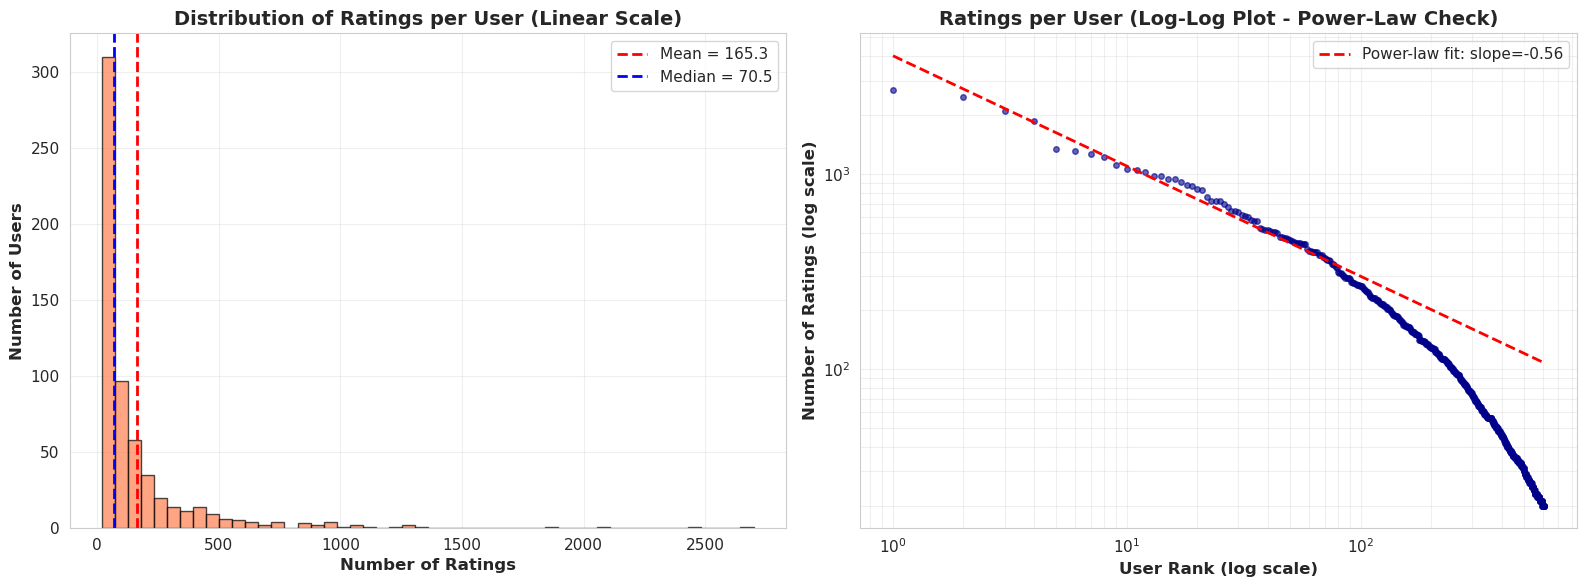


✓ Visualization saved as 'ratings_per_user_distribution.png'


In [115]:
# Visualize ratings per user
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Regular histogram
ax1 = axes[0]
ax1.hist(ratings_per_user['num_ratings'], bins=50, edgecolor='black', 
         alpha=0.7, color='coral')
ax1.axvline(ratings_per_user['num_ratings'].mean(), color='red', 
            linestyle='--', linewidth=2, label=f'Mean = {ratings_per_user["num_ratings"].mean():.1f}')
ax1.axvline(ratings_per_user['num_ratings'].median(), color='blue', 
            linestyle='--', linewidth=2, label=f'Median = {ratings_per_user["num_ratings"].median():.1f}')
ax1.set_xlabel('Number of Ratings', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Users', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Ratings per User (Linear Scale)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Right: Log-log plot to show power-law
ax2 = axes[1]
sorted_ratings = np.sort(ratings_per_user['num_ratings'].values)[::-1]
ranks = np.arange(1, len(sorted_ratings) + 1)
ax2.loglog(ranks, sorted_ratings, 'o', alpha=0.6, markersize=4, color='darkblue')
ax2.set_xlabel('User Rank (log scale)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Ratings (log scale)', fontsize=12, fontweight='bold')
ax2.set_title('Ratings per User (Log-Log Plot - Power-Law Check)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

# Add power-law reference line
# Fit a line to the log-log data
log_ranks = np.log10(ranks[ranks > 0])
log_ratings = np.log10(sorted_ratings[ranks > 0])
slope, intercept = np.polyfit(log_ranks[:100], log_ratings[:100], 1)
ax2.plot(ranks, 10**(intercept + slope * np.log10(ranks)), 'r--', 
         linewidth=2, label=f'Power-law fit: slope={slope:.2f}')
ax2.legend(fontsize=11)

plt.tight_layout()
# plt.savefig('ratings_per_user_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'ratings_per_user_distribution.png'")

### 2.2 Ratings Per Movie Distribution

In [116]:
# Calculate ratings per movie
ratings_per_movie = ratings_clean.groupby('movieId').size().reset_index(name='num_ratings')

print("="*80)
print("RATINGS PER MOVIE STATISTICS")
print("="*80)
print(ratings_per_movie['num_ratings'].describe())

print(f"\n📊 Movie Popularity Breakdown:")
print(f"   • Movies with < 5 ratings:    {len(ratings_per_movie[ratings_per_movie['num_ratings'] < 5]):,}")
print(f"   • Movies with 5-20 ratings:   {len(ratings_per_movie[(ratings_per_movie['num_ratings'] >= 5) & (ratings_per_movie['num_ratings'] < 20)]):,}")
print(f"   • Movies with 20-100 ratings: {len(ratings_per_movie[(ratings_per_movie['num_ratings'] >= 20) & (ratings_per_movie['num_ratings'] < 100)]):,}")
print(f"   • Movies with ≥100 ratings:   {len(ratings_per_movie[ratings_per_movie['num_ratings'] >= 100]):,}")

RATINGS PER MOVIE STATISTICS
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: num_ratings, dtype: float64

📊 Movie Popularity Breakdown:
   • Movies with < 5 ratings:    6,074
   • Movies with 5-20 ratings:   2,353
   • Movies with 20-100 ratings: 1,159
   • Movies with ≥100 ratings:   138


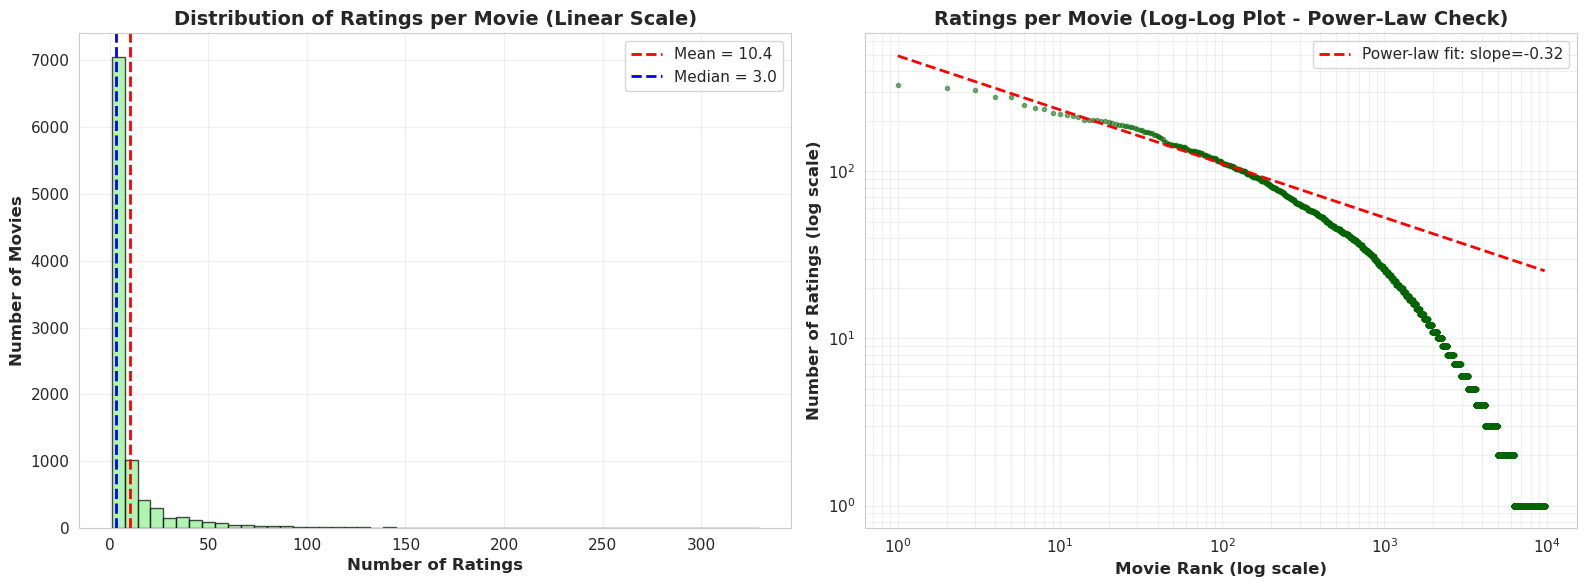


✓ Visualization saved as 'ratings_per_movie_distribution.png'


In [117]:
# Visualize ratings per movie
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Regular histogram
ax1 = axes[0]
ax1.hist(ratings_per_movie['num_ratings'], bins=50, edgecolor='black', 
         alpha=0.7, color='lightgreen')
ax1.axvline(ratings_per_movie['num_ratings'].mean(), color='red', 
            linestyle='--', linewidth=2, label=f'Mean = {ratings_per_movie["num_ratings"].mean():.1f}')
ax1.axvline(ratings_per_movie['num_ratings'].median(), color='blue', 
            linestyle='--', linewidth=2, label=f'Median = {ratings_per_movie["num_ratings"].median():.1f}')
ax1.set_xlabel('Number of Ratings', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Movies', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Ratings per Movie (Linear Scale)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Right: Log-log plot to show power-law
ax2 = axes[1]
sorted_ratings_movie = np.sort(ratings_per_movie['num_ratings'].values)[::-1]
ranks_movie = np.arange(1, len(sorted_ratings_movie) + 1)
ax2.loglog(ranks_movie, sorted_ratings_movie, 'o', alpha=0.5, markersize=3, color='darkgreen')
ax2.set_xlabel('Movie Rank (log scale)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Ratings (log scale)', fontsize=12, fontweight='bold')
ax2.set_title('Ratings per Movie (Log-Log Plot - Power-Law Check)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

# Add power-law reference line
log_ranks_movie = np.log10(ranks_movie[ranks_movie > 0])
log_ratings_movie = np.log10(sorted_ratings_movie[ranks_movie > 0])
slope_movie, intercept_movie = np.polyfit(log_ranks_movie[:200], log_ratings_movie[:200], 1)
ax2.plot(ranks_movie, 10**(intercept_movie + slope_movie * np.log10(ranks_movie)), 'r--', 
         linewidth=2, label=f'Power-law fit: slope={slope_movie:.2f}')
ax2.legend(fontsize=11)

plt.tight_layout()
# plt.savefig('ratings_per_movie_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'ratings_per_movie_distribution.png'")

### Power-Law Analysis

In [118]:
print("="*80)
print("POWER-LAW BEHAVIOR ANALYSIS")
print("="*80)

print("\n📊 Users (Ratings per User):")
print(f"   • Power-law slope: {slope:.4f}")
print(f"   • Interpretation: A slope around -1 indicates strong power-law behavior")

print("\n📊 Movies (Ratings per Movie):")
print(f"   • Power-law slope: {slope_movie:.4f}")
print(f"   • Interpretation: A slope around -1 indicates strong power-law behavior")

print("\n💡 Power-Law Implications:")
print("   The log-log plots show approximately linear relationships, indicating")
print("   power-law distributions (also known as 'long-tail' distributions).")
print("")
print("   This means:")
print("   • A FEW users rate MANY movies (power users)")
print("   • MOST users rate FEW movies (casual users)")
print("   • A FEW movies receive MANY ratings (popular/blockbusters)")
print("   • MOST movies receive FEW ratings (niche/obscure films)")
print("")
print("   This is the 'Rich Get Richer' or 'Pareto Principle' (80/20 rule) in action!")

POWER-LAW BEHAVIOR ANALYSIS

📊 Users (Ratings per User):
   • Power-law slope: -0.5648
   • Interpretation: A slope around -1 indicates strong power-law behavior

📊 Movies (Ratings per Movie):
   • Power-law slope: -0.3226
   • Interpretation: A slope around -1 indicates strong power-law behavior

💡 Power-Law Implications:
   The log-log plots show approximately linear relationships, indicating
   power-law distributions (also known as 'long-tail' distributions).

   This means:
   • A FEW users rate MANY movies (power users)
   • MOST users rate FEW movies (casual users)
   • A FEW movies receive MANY ratings (popular/blockbusters)
   • MOST movies receive FEW ratings (niche/obscure films)

   This is the 'Rich Get Richer' or 'Pareto Principle' (80/20 rule) in action!


---
## 3. Genre Distribution Across Movies

We'll analyze which genres are most common in the dataset.

In [119]:
# Extract all genres from movies
# Genres are pipe-separated (e.g., "Action|Adventure|Sci-Fi")
all_genres = []

for genres_str in movies_clean['genres']:
    if pd.notna(genres_str) and genres_str != '(no genres listed)':
        genres = genres_str.split('|')
        all_genres.extend(genres)

# Count genre occurrences
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values('Count', ascending=False)

print("="*80)
print("GENRE DISTRIBUTION")
print("="*80)
print(genre_df)
print(f"\nTotal unique genres: {len(genre_df)}")
print(f"Total genre tags: {sum(genre_counts.values()):,}")

GENRE DISTRIBUTION
          Genre  Count
6         Drama   4361
3        Comedy   3756
9      Thriller   1894
7        Action   1828
5       Romance   1596
0     Adventure   1263
8         Crime   1199
12       Sci-Fi    980
10       Horror    978
4       Fantasy    779
2      Children    664
1     Animation    611
11      Mystery    573
15  Documentary    440
13          War    382
14      Musical    334
17      Western    167
16         IMAX    158
18    Film-Noir     87

Total unique genres: 19
Total genre tags: 22,050


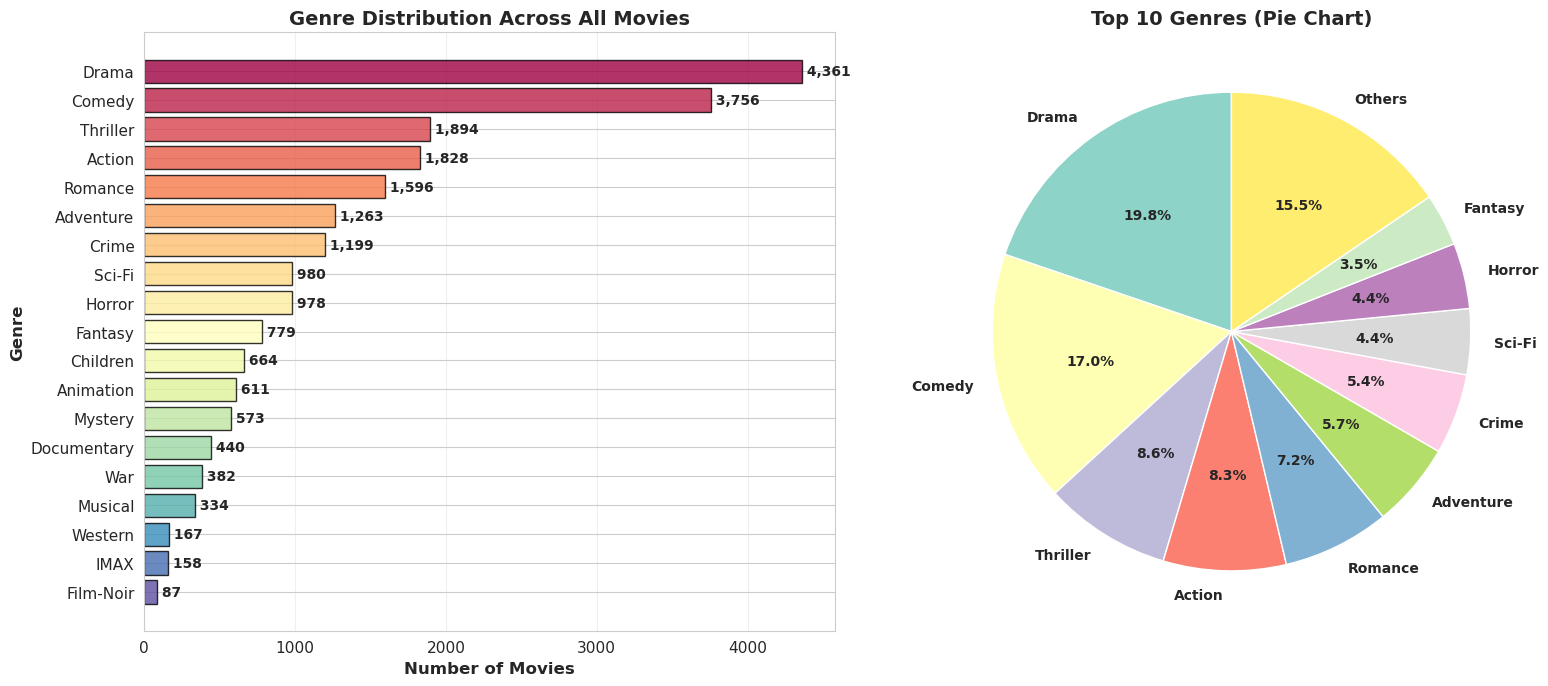


✓ Visualization saved as 'genre_distribution.png'


In [120]:
# Visualize genre distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Bar chart
ax1 = axes[0]
colors = plt.cm.Spectral(np.linspace(0, 1, len(genre_df)))
bars = ax1.barh(genre_df['Genre'], genre_df['Count'], color=colors, edgecolor='black', alpha=0.8)
ax1.set_xlabel('Number of Movies', fontsize=12, fontweight='bold')
ax1.set_ylabel('Genre', fontsize=12, fontweight='bold')
ax1.set_title('Genre Distribution Across All Movies', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Add count labels
for i, (genre, count) in enumerate(zip(genre_df['Genre'], genre_df['Count'])):
    ax1.text(count, i, f' {count:,}', va='center', fontsize=10, fontweight='bold')

# Right: Pie chart (top 10 genres)
ax2 = axes[1]
top_genres = genre_df.head(10)
other_count = genre_df.iloc[10:]['Count'].sum() if len(genre_df) > 10 else 0

pie_labels = list(top_genres['Genre'])
pie_values = list(top_genres['Count'])

if other_count > 0:
    pie_labels.append('Others')
    pie_values.append(other_count)

colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_labels)))
wedges, texts, autotexts = ax2.pie(pie_values, labels=pie_labels, autopct='%1.1f%%',
                                     colors=colors_pie, startangle=90,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Top 10 Genres (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
# plt.savefig('genre_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'genre_distribution.png'")

In [121]:
# Genre combination analysis
print("\n📊 Genre Combination Analysis:")
movies_with_genres = movies_clean[movies_clean['genres'] != '(no genres listed)']
genres_per_movie = movies_with_genres['genres'].str.split('|').str.len()

print(f"   • Average genres per movie: {genres_per_movie.mean():.2f}")
print(f"   • Median genres per movie: {genres_per_movie.median():.0f}")
print(f"   • Max genres per movie: {genres_per_movie.max()}")
print(f"   • Movies with no genre listed: {len(movies_clean[movies_clean['genres'] == '(no genres listed)'])}")

print("\n📈 Distribution of Number of Genres per Movie:")
print(genres_per_movie.value_counts().sort_index())


📊 Genre Combination Analysis:
   • Average genres per movie: 2.27
   • Median genres per movie: 2
   • Max genres per movie: 10
   • Movies with no genre listed: 34

📈 Distribution of Number of Genres per Movie:
genres
1     2817
2     3218
3     2338
4      987
5      271
6       63
7       12
8        1
10       1
Name: count, dtype: int64


---
## 4. Cold-Start Problem Analysis

The **cold-start problem** refers to the difficulty of making recommendations for:
- New users with few ratings (user cold-start)
- New movies with few ratings (item cold-start)



In [122]:
# Define cold-start threshold
COLD_START_THRESHOLD = 5

# User cold-start analysis
cold_start_users = ratings_per_user[ratings_per_user['num_ratings'] < COLD_START_THRESHOLD]
num_cold_start_users = len(cold_start_users)
pct_cold_start_users = (num_cold_start_users / len(ratings_per_user)) * 100

# Movie cold-start analysis
cold_start_movies = ratings_per_movie[ratings_per_movie['num_ratings'] < COLD_START_THRESHOLD]
num_cold_start_movies = len(cold_start_movies)
pct_cold_start_movies = (num_cold_start_movies / len(ratings_per_movie)) * 100

print("="*80)
print("COLD-START PROBLEM ANALYSIS")
print("="*80)

print(f"\n👤 USER COLD-START (< {COLD_START_THRESHOLD} ratings):")
print(f"   • Total users: {len(ratings_per_user):,}")
print(f"   • Cold-start users: {num_cold_start_users:,}")
print(f"   • Percentage: {pct_cold_start_users:.2f}%")

print(f"\n🎬 MOVIE COLD-START (< {COLD_START_THRESHOLD} ratings):")
print(f"   • Total movies: {len(ratings_per_movie):,}")
print(f"   • Cold-start movies: {num_cold_start_movies:,}")
print(f"   • Percentage: {pct_cold_start_movies:.2f}%")

COLD-START PROBLEM ANALYSIS

👤 USER COLD-START (< 5 ratings):
   • Total users: 610
   • Cold-start users: 0
   • Percentage: 0.00%

🎬 MOVIE COLD-START (< 5 ratings):
   • Total movies: 9,724
   • Cold-start movies: 6,074
   • Percentage: 62.46%


In [123]:
# Detailed breakdown for different thresholds
thresholds = [1, 5, 10, 20, 50]

print("\n📊 Detailed Cold-Start Analysis:")
print("\nUSERS:")
print(f"{'Threshold':<12} {'Count':<10} {'Percentage':<12}")
print("-" * 34)
for threshold in thresholds:
    count = len(ratings_per_user[ratings_per_user['num_ratings'] < threshold])
    pct = (count / len(ratings_per_user)) * 100
    print(f"< {threshold:<10} {count:<10,} {pct:<12.2f}%")

print("\nMOVIES:")
print(f"{'Threshold':<12} {'Count':<10} {'Percentage':<12}")
print("-" * 34)
for threshold in thresholds:
    count = len(ratings_per_movie[ratings_per_movie['num_ratings'] < threshold])
    pct = (count / len(ratings_per_movie)) * 100
    print(f"< {threshold:<10} {count:<10,} {pct:<12.2f}%")


📊 Detailed Cold-Start Analysis:

USERS:
Threshold    Count      Percentage  
----------------------------------
< 1          0          0.00        %
< 5          0          0.00        %
< 10         0          0.00        %
< 20         0          0.00        %
< 50         225        36.89       %

MOVIES:
Threshold    Count      Percentage  
----------------------------------
< 1          0          0.00        %
< 5          6,074      62.46       %
< 10         7,455      76.67       %
< 20         8,427      86.66       %
< 50         9,274      95.37       %


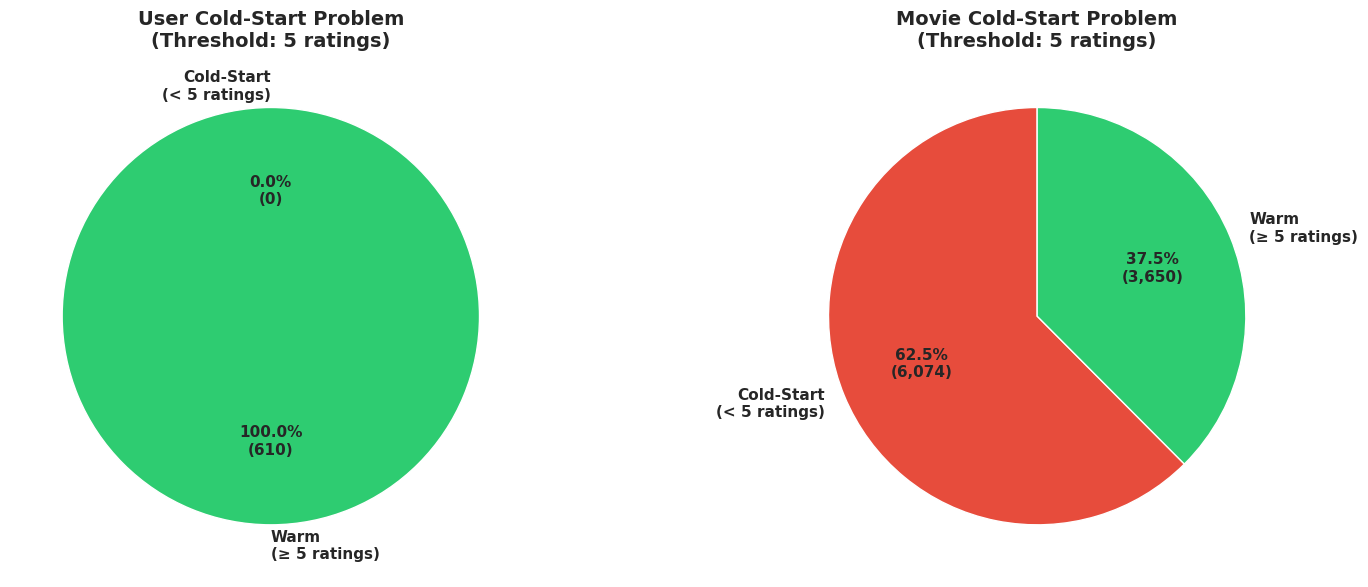


✓ Visualization saved as 'cold_start_analysis.png'


In [124]:
# Visualize cold-start problem
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Users
ax1 = axes[0]
user_categories = ['Cold-Start\n(< 5 ratings)', 'Warm\n(≥ 5 ratings)']
user_counts = [num_cold_start_users, len(ratings_per_user) - num_cold_start_users]
colors_user = ['#e74c3c', '#2ecc71']

wedges1, texts1, autotexts1 = ax1.pie(user_counts, labels=user_categories, 
                                        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(user_counts)):,})',
                                        colors=colors_user, startangle=90,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title(f'User Cold-Start Problem\n(Threshold: {COLD_START_THRESHOLD} ratings)', 
              fontsize=14, fontweight='bold')

# Right: Movies
ax2 = axes[1]
movie_categories = ['Cold-Start\n(< 5 ratings)', 'Warm\n(≥ 5 ratings)']
movie_counts = [num_cold_start_movies, len(ratings_per_movie) - num_cold_start_movies]
colors_movie = ['#e74c3c', '#2ecc71']

wedges2, texts2, autotexts2 = ax2.pie(movie_counts, labels=movie_categories,
                                        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(movie_counts)):,})',
                                        colors=colors_movie, startangle=90,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title(f'Movie Cold-Start Problem\n(Threshold: {COLD_START_THRESHOLD} ratings)', 
              fontsize=14, fontweight='bold')

plt.tight_layout()
# plt.savefig('cold_start_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'cold_start_analysis.png'")

### Cold-Start Discussion

In [125]:
print("="*80)
print("COLD-START PROBLEM DISCUSSION")
print("="*80)

print("  1. USER COLD-START: New users with few ratings")
print("  2. ITEM COLD-START: New movies with few ratings")

print("\n📊 Findings in This Dataset:")
print("-" * 80)
print(f"  • {pct_cold_start_users:.1f}% of users have < {COLD_START_THRESHOLD} ratings (user cold-start)")
print(f"  • {pct_cold_start_movies:.1f}% of movies have < {COLD_START_THRESHOLD} ratings (item cold-start)")

print("\n💡 Implications for Recommendation Algorithms:")
print("-" * 80)
print("  1. COLLABORATIVE FILTERING:")
print("     - Struggles with cold-start users/items (needs interaction history)")
print("     - User-User CF: Can't find similar users for cold-start users")
print("     - Item-Item CF: Can't compute similarities for cold-start movies")
print()
print("  2. CONTENT-BASED FILTERING:")
print("     - Better for item cold-start (uses movie metadata like genres)")
print("     - Still struggles with user cold-start (needs user preferences)")
print()
print("  3. MATRIX FACTORIZATION:")
print("     - Cannot generate recommendations for completely new users/items")
print("     - Needs at least some ratings to learn latent factors")

print("\n🔧 Common Solutions:")
print("-" * 80)
print("  • Hybrid approaches (combine collaborative + content-based)")
print("  • Popularity-based recommendations for new users")
print("  • Use demographic/genre information for new items")
print("  • Active learning: Ask new users to rate popular movies")
print("  • Transfer learning from other domains")

COLD-START PROBLEM DISCUSSION
  1. USER COLD-START: New users with few ratings
  2. ITEM COLD-START: New movies with few ratings

📊 Findings in This Dataset:
--------------------------------------------------------------------------------
  • 0.0% of users have < 5 ratings (user cold-start)
  • 62.5% of movies have < 5 ratings (item cold-start)

💡 Implications for Recommendation Algorithms:
--------------------------------------------------------------------------------
  1. COLLABORATIVE FILTERING:
     - Struggles with cold-start users/items (needs interaction history)
     - User-User CF: Can't find similar users for cold-start users
     - Item-Item CF: Can't compute similarities for cold-start movies

  2. CONTENT-BASED FILTERING:
     - Better for item cold-start (uses movie metadata like genres)
     - Still struggles with user cold-start (needs user preferences)

  3. MATRIX FACTORIZATION:
     - Cannot generate recommendations for completely new users/items
     - Needs at lea

---
## 5. Mean-Centering Analysis

**Mean-centering** normalizes ratings by subtracting each user's mean rating from their ratings.

**Why?** Different users have different rating scales:
- Some users are "harsh critics" (average rating ~2.5)
- Some users are "generous raters" (average rating ~4.5)

Mean-centering makes ratings comparable across users by focusing on **relative preferences** rather than absolute values.

In [126]:
# Calculate user mean ratings
user_mean_ratings = ratings_clean.groupby('userId')['rating'].mean()

print("="*80)
print("USER MEAN RATING STATISTICS")
print("="*80)
print(user_mean_ratings.describe())

print("\n📊 Distribution of User Mean Ratings:")
print(f"   • Min mean rating: {user_mean_ratings.min():.3f}")
print(f"   • Max mean rating: {user_mean_ratings.max():.3f}")
print(f"   • Range: {user_mean_ratings.max() - user_mean_ratings.min():.3f}")
print(f"   • Std deviation: {user_mean_ratings.std():.3f}")

USER MEAN RATING STATISTICS
count    610.000000
mean       3.657222
std        0.480635
min        1.275000
25%        3.360000
50%        3.694385
75%        3.997500
max        5.000000
Name: rating, dtype: float64

📊 Distribution of User Mean Ratings:
   • Min mean rating: 1.275
   • Max mean rating: 5.000
   • Range: 3.725
   • Std deviation: 0.481


In [127]:
# Apply mean-centering to utility matrix
utility_matrix_centered = utility_matrix.sub(utility_matrix.mean(axis=1), axis=0)

print("\n✓ Mean-centered utility matrix created!")
print(f"Shape: {utility_matrix_centered.shape}")
print("\nSample of mean-centered matrix (first 5 users, first 10 movies):")
print(utility_matrix_centered.iloc[:5, :10])

# Verify mean-centering worked
user_means_after = utility_matrix_centered.mean(axis=1)
print(f"\n✓ Verification: Mean of each row should be ~0")
print(f"   Average row mean after centering: {user_means_after.mean():.10f}")
print(f"   Max absolute row mean: {abs(user_means_after).max():.10f}")


✓ Mean-centered utility matrix created!
Shape: (610, 9724)

Sample of mean-centered matrix (first 5 users, first 10 movies):
               1   2         3   4   5         6   7   8   9  10
userId                                                          
1      -0.366379 NaN -0.366379 NaN NaN -0.366379 NaN NaN NaN NaN
2            NaN NaN       NaN NaN NaN       NaN NaN NaN NaN NaN
3            NaN NaN       NaN NaN NaN       NaN NaN NaN NaN NaN
4            NaN NaN       NaN NaN NaN       NaN NaN NaN NaN NaN
5       0.363636 NaN       NaN NaN NaN       NaN NaN NaN NaN NaN

✓ Verification: Mean of each row should be ~0
   Average row mean after centering: 0.0000000000
   Max absolute row mean: 0.0000000000


In [128]:
# Create ratings DataFrame with mean-centered values
ratings_centered = ratings_clean.copy()
ratings_centered['rating_centered'] = ratings_centered.apply(
    lambda row: row['rating'] - user_mean_ratings[row['userId']], axis=1
)

print("Sample of centered ratings:")
display(ratings_centered[['userId', 'movieId', 'rating', 'rating_centered']].head(20))

Sample of centered ratings:


,userId,movieId,rating,rating_centered
0,1,1,4.0,-0.366379
1,1,3,4.0,-0.366379
2,1,6,4.0,-0.366379
3,1,47,5.0,0.633621
4,1,50,5.0,0.633621
5,1,70,3.0,-1.366379
6,1,101,5.0,0.633621
7,1,110,4.0,-0.366379
8,1,151,5.0,0.633621
9,1,157,5.0,0.633621


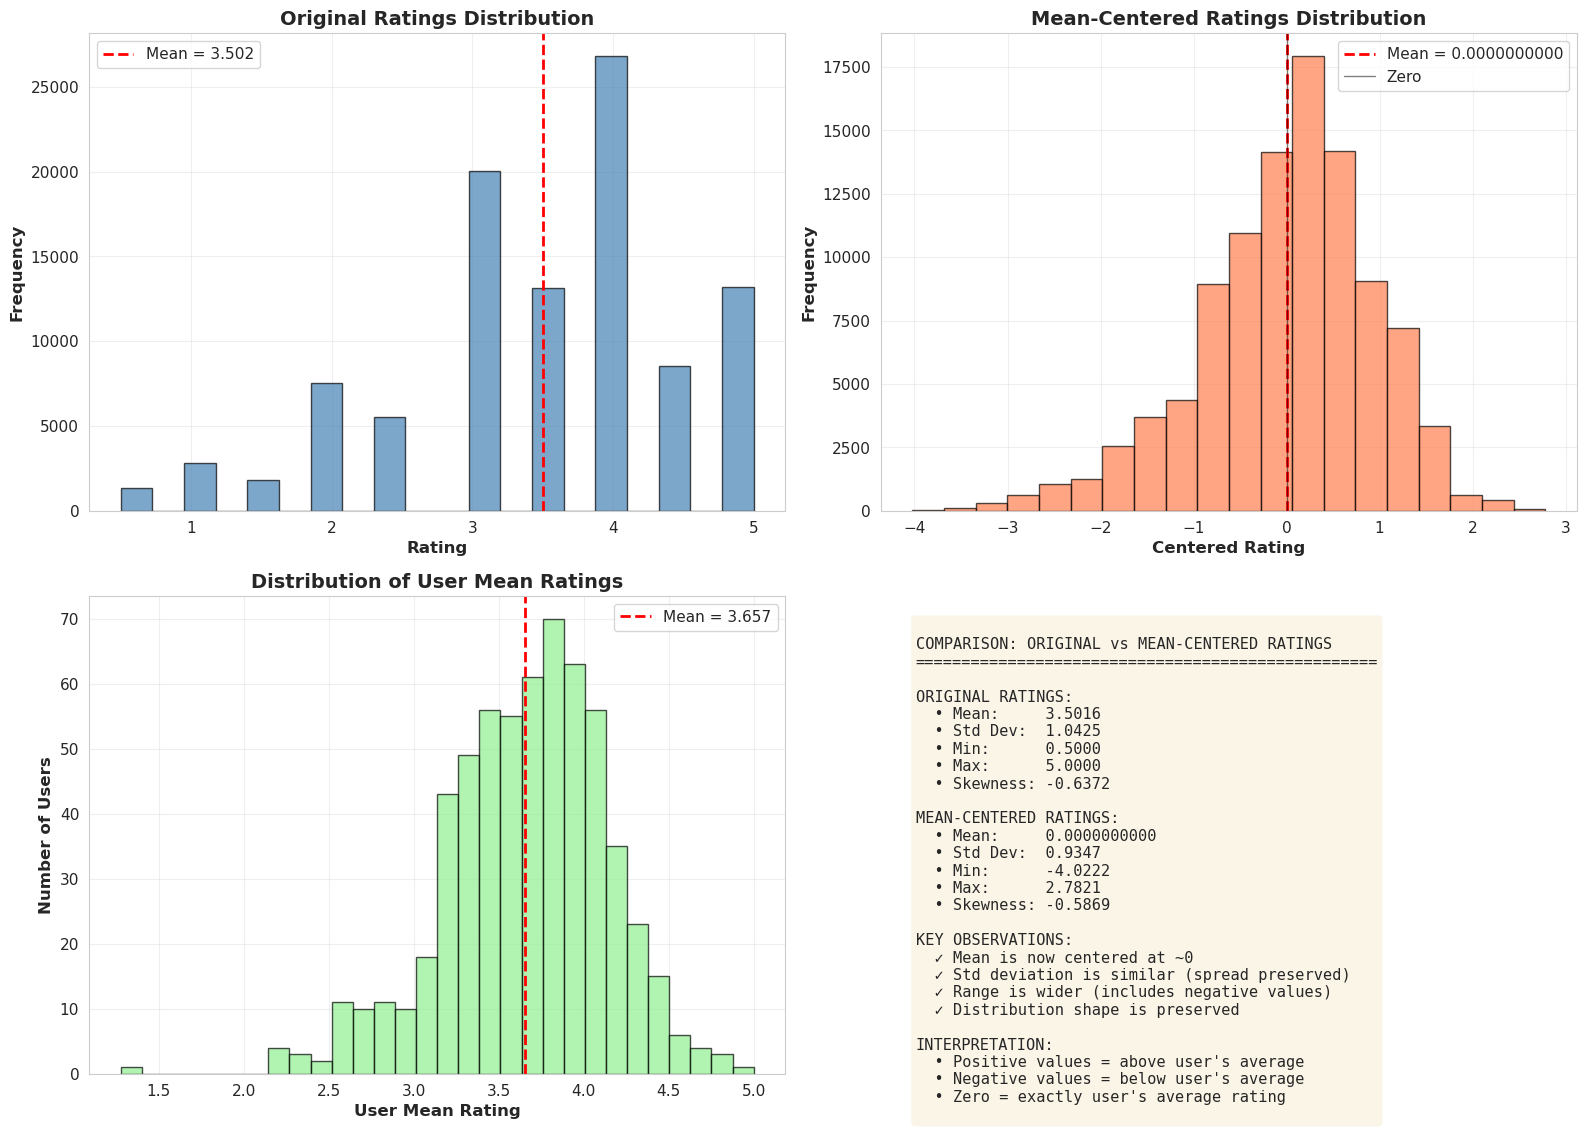


✓ Visualization saved as 'mean_centering_analysis.png'


In [129]:
# Visualize the effect of mean-centering
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: Original rating distribution
ax1 = axes[0, 0]
ax1.hist(ratings_clean['rating'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(ratings_clean['rating'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {ratings_clean["rating"].mean():.3f}')
ax1.set_xlabel('Rating', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Original Ratings Distribution', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Top-right: Mean-centered rating distribution
ax2 = axes[0, 1]
ax2.hist(ratings_centered['rating_centered'], bins=20, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(ratings_centered['rating_centered'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {ratings_centered["rating_centered"].mean():.10f}')
ax2.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Zero')
ax2.set_xlabel('Centered Rating', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Mean-Centered Ratings Distribution', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Bottom-left: User mean ratings distribution
ax3 = axes[1, 0]
ax3.hist(user_mean_ratings, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
ax3.axvline(user_mean_ratings.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {user_mean_ratings.mean():.3f}')
ax3.set_xlabel('User Mean Rating', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Users', fontsize=12, fontweight='bold')
ax3.set_title('Distribution of User Mean Ratings', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Bottom-right: Comparison of statistics
ax4 = axes[1, 1]
ax4.axis('off')

stats_text = f"""
COMPARISON: ORIGINAL vs MEAN-CENTERED RATINGS
{'='*50}

ORIGINAL RATINGS:
  • Mean:     {ratings_clean['rating'].mean():.4f}
  • Std Dev:  {ratings_clean['rating'].std():.4f}
  • Min:      {ratings_clean['rating'].min():.4f}
  • Max:      {ratings_clean['rating'].max():.4f}
  • Skewness: {ratings_clean['rating'].skew():.4f}

MEAN-CENTERED RATINGS:
  • Mean:     {ratings_centered['rating_centered'].mean():.10f}
  • Std Dev:  {ratings_centered['rating_centered'].std():.4f}
  • Min:      {ratings_centered['rating_centered'].min():.4f}
  • Max:      {ratings_centered['rating_centered'].max():.4f}
  • Skewness: {ratings_centered['rating_centered'].skew():.4f}

KEY OBSERVATIONS:
  ✓ Mean is now centered at ~0
  ✓ Std deviation is similar (spread preserved)
  ✓ Range is wider (includes negative values)
  ✓ Distribution shape is preserved

INTERPRETATION:
  • Positive values = above user's average
  • Negative values = below user's average
  • Zero = exactly user's average rating
"""

ax4.text(0.05, 0.95, stats_text, transform=ax4.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
# plt.savefig('mean_centering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'mean_centering_analysis.png'")

### Mean-Centering Discussion

In [130]:
print("="*80)
print("MEAN-CENTERING DISCUSSION")
print("="*80)

print("\n🎯 Why Mean-Center?")
print("-" * 80)
print("Different users have different rating behaviors:")
print()

# Find example users with different mean ratings
harsh_critic = user_mean_ratings.idxmin()
generous_rater = user_mean_ratings.idxmax()

print(f"Example: User {harsh_critic} (Harsh Critic)")
print(f"  • Mean rating: {user_mean_ratings[harsh_critic]:.3f}")
print(f"  • A rating of 3.0 from this user means 'above average' for them")
print()
print(f"Example: User {generous_rater} (Generous Rater)")
print(f"  • Mean rating: {user_mean_ratings[generous_rater]:.3f}")
print(f"  • A rating of 4.0 from this user might mean 'below average' for them")
print()
print("WITHOUT mean-centering:")
print("  • We'd treat all 4.0 ratings the same")
print("  • This ignores user rating tendencies")
print()
print("WITH mean-centering:")
print("  • We focus on how much users DEVIATE from their personal average")
print("  • Positive = user liked it MORE than usual")
print("  • Negative = user liked it LESS than usual")

print("\n📊 Impact on Collaborative Filtering:")
print("-" * 80)
print("Mean-centering is ESSENTIAL for cosine similarity in CF because:")
print("  1. It removes user bias (some users rate everything high/low)")
print("  2. Makes user preferences comparable")
print("  3. Improves similarity calculations")
print("  4. Focuses on RELATIVE preferences rather than absolute ratings")

print("\n🔍 Example Interpretation:")
print("-" * 80)
# Get some example ratings
example_user = ratings_centered.groupby('userId').size().idxmax()  # User with most ratings
example_ratings = ratings_centered[ratings_centered['userId'] == example_user].head(5)
print(f"\nUser {example_user} (mean rating: {user_mean_ratings[example_user]:.3f}):")
print()
for _, row in example_ratings.iterrows():
    original = row['rating']
    centered = row['rating_centered']
    if centered > 0:
        interpretation = f"LIKED MORE than average (by {abs(centered):.2f})"
    elif centered < 0:
        interpretation = f"LIKED LESS than average (by {abs(centered):.2f})"
    else:
        interpretation = "Exactly at their average"
    print(f"  Movie {row['movieId']}: {original:.1f} → {centered:+.2f} | {interpretation}")

MEAN-CENTERING DISCUSSION

🎯 Why Mean-Center?
--------------------------------------------------------------------------------
Different users have different rating behaviors:

Example: User 442 (Harsh Critic)
  • Mean rating: 1.275
  • A rating of 3.0 from this user means 'above average' for them

Example: User 53 (Generous Rater)
  • Mean rating: 5.000
  • A rating of 4.0 from this user might mean 'below average' for them

WITHOUT mean-centering:
  • We'd treat all 4.0 ratings the same
  • This ignores user rating tendencies

WITH mean-centering:
  • We focus on how much users DEVIATE from their personal average
  • Positive = user liked it MORE than usual
  • Negative = user liked it LESS than usual

📊 Impact on Collaborative Filtering:
--------------------------------------------------------------------------------
Mean-centering is ESSENTIAL for cosine similarity in CF because:
  1. It removes user bias (some users rate everything high/low)
  2. Makes user preferences comparable
 

In [131]:
# Save mean-centered data for future use
utility_matrix_centered.to_csv("utility_matrix_centered.csv")
ratings_centered.to_csv("ratings_centered.csv", index=False)

print("\n✓ Saved mean-centered datasets:")
print("  • utility_matrix_centered.csv")
print("  • ratings_centered.csv")


✓ Saved mean-centered datasets:
  • utility_matrix_centered.csv
  • ratings_centered.csv


---
## Summary for Report

Key findings from the exploratory data analysis.

In [132]:
summary_text = f"""
{'='*80}
PART 1.2: EXPLORATORY DATA ANALYSIS - SUMMARY
{'='*80}

1. RATING DISTRIBUTION:
   • Mean rating: {ratings_clean['rating'].mean():.3f}
   • Median rating: {ratings_clean['rating'].median():.3f}
   • Skewness: {skewness:.4f} ({skew_interpretation})
   • Users tend to rate movies they LIKE (positive bias)
   • High ratings (≥4.0): {high_ratings/total_ratings*100:.1f}% of all ratings

2. POWER-LAW BEHAVIOR:
   • Ratings per user: Power-law slope = {slope:.4f}
   • Ratings per movie: Power-law slope = {slope_movie:.4f}
   • OBSERVATION: Classic "long-tail" distribution
     - Few users rate many movies (power users)
     - Most users rate few movies (casual users)
     - Few movies are very popular (blockbusters)
     - Most movies have few ratings (niche films)

3. GENRE DISTRIBUTION:
   • Total unique genres: {len(genre_df)}
   • Most common: {genre_df.iloc[0]['Genre']} ({genre_df.iloc[0]['Count']:,} movies)
   • Average genres per movie: {genres_per_movie.mean():.2f}
   • Movies typically have multiple genre tags

4. COLD-START PROBLEM:
   • Users with < {COLD_START_THRESHOLD} ratings: {num_cold_start_users:,} ({pct_cold_start_users:.2f}%)
   • Movies with < {COLD_START_THRESHOLD} ratings: {num_cold_start_movies:,} ({pct_cold_start_movies:.2f}%)
   • IMPLICATION: {pct_cold_start_movies:.0f}% of movies face item cold-start
   • This will challenge collaborative filtering approaches

5. MEAN-CENTERING:
   • User mean ratings range: {user_mean_ratings.min():.3f} to {user_mean_ratings.max():.3f}
   • Different users have different rating scales
   • After centering: mean = {ratings_centered['rating_centered'].mean():.10f} (≈0)
   • BENEFIT: Removes user bias, focuses on relative preferences
   • ESSENTIAL for accurate collaborative filtering

KEY INSIGHTS FOR RECOMMENDATION ALGORITHMS:
  • Sparsity + power-law = challenging but realistic dataset
  • Cold-start problem significant for movies more than users
  • Mean-centering will improve collaborative filtering accuracy
  • Genre information can help with content-based filtering
  • Positive rating bias suggests users rate what they like

{'='*80}
"""

print(summary_text)

# Save summary
with open("part1_2_summary.txt", "w") as f:
    f.write(summary_text)

print("\n✓ Summary saved to 'part1_2_summary.txt'")


PART 1.2: EXPLORATORY DATA ANALYSIS - SUMMARY

1. RATING DISTRIBUTION:
   • Mean rating: 3.502
   • Median rating: 3.500
   • Skewness: -0.6372 (NEGATIVELY SKEWED (left-skewed))
   • Users tend to rate movies they LIKE (positive bias)
   • High ratings (≥4.0): 48.2% of all ratings

2. POWER-LAW BEHAVIOR:
   • Ratings per user: Power-law slope = -0.5648
   • Ratings per movie: Power-law slope = -0.3226
   • OBSERVATION: Classic "long-tail" distribution
     - Few users rate many movies (power users)
     - Most users rate few movies (casual users)
     - Few movies are very popular (blockbusters)
     - Most movies have few ratings (niche films)

3. GENRE DISTRIBUTION:
   • Total unique genres: 19
   • Most common: Drama (4,361 movies)
   • Average genres per movie: 2.27
   • Movies typically have multiple genre tags

4. COLD-START PROBLEM:
   • Users with < 5 ratings: 0 (0.00%)
   • Movies with < 5 ratings: 6,074 (62.46%)
   • IMPLICATION: 62% of movies face item cold-start
   • This 

---
## Conclusion

We have successfully completed Part 1.2 of the project:

✅ **Rating Distribution**: Negatively skewed, users prefer to rate movies they like

✅ **Power-Law Behavior**: Clear long-tail distributions for both users and movies

✅ **Genre Analysis**: Drama is most common, most movies have multiple genres

✅ **Cold-Start Problem**: Identified significant challenge, especially for movies

✅ **Mean-Centering**: Successfully normalized ratings by user bias


#  Handoff Guide for Parts 2 & 3

You can start your new notebooks simply by using `pd.read_csv()` on the files below.

---

##  1. Files for Part 2: Content-Based Filtering
**Rule:** Do NOT use the mean-centered data here. Use the "shifted" ratings!

*  **cbf_item_profiles.csv**
  * **What's inside:** The `movieId`, `title`, One-Hot Encoded Genres (binary 1s and 0s), plus the `avg_rating` and `num_ratings` (I handled the cold-start missing values using the global average of 3.5!).
*  **cbf_shifted_ratings.csv**
  * **What it is:** The standard ratings table, but with a new `shifted_rating` column.
  * **How to use it:** When calculating the User Profile (Part 2.2), you must multiply the user's movies in the `item_profiles` table by this `shifted_rating` column ($Rating - 3.0$), NOT the raw rating.

---

##  2. Files for Part 3: Collaborative Filtering
**Rule:** Do NOT use genres or the `movies.csv` file here. Use the mean-centered matrices!

***cf_user_user_matrix.csv**
  * **What it is:** The Mean-Centered Utility Matrix for Part 3.2.
  * **What's inside:** Rows are Users, Columns are Movies. I subtracted each user's personal average from their ratings. Missing values (`NaN`) are filled with `0.0` so your Cosine Similarity math won't crash (0 is mathematically neutral here).
* **cf_item_item_matrix.csv**
  * **What it is:** The exact same mean-centered matrix, but transposed (`.T`) for Part 3.3.
  * **What's inside:** Rows are Movies, Columns are Users.

**Critical Reminder for Part 3.1:** When you build the similarity function, the PDF says: *"only consider items co-rated by both users/items"*. You must filter the vectors to only look at overlapping movies before applying Cosine Similarity!

---

##  3. General Files 
If you need the raw, cleaned data use these:
* **ratings_clean.csv** (Duplicates removed, kept the most recent timestamp).
* **movies_clean.csv** (Cleaned base movie data).
